# Day 5 & 6 — Neural Networks

This notebook covers:

- **Part 1** — Neural Network with sklearn's `MLPClassifier`
- **Part 2** — Neural Network with TensorFlow / Keras

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

---
# Part 1 — sklearn MLPClassifier

`MLPClassifier` (Multi-Layer Perceptron) implements a neural network internally:
- Configurable hidden layers and neurons
- Choice of activation (`relu`, `tanh`, `logistic`)
- Optimizers: `adam`, `sgd`, `lbfgs`
- Automatic forward/backward propagation and weight updates

## 1. Load and Prepare the Data

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
print(data)


{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

In [5]:
X, y = data.data, data.target
print("Feature matrix shape:", X.shape)
print("Target classes      :", data.target_names, "(0/1)")

# split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# scale features (neural nets train much better on scaled data)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train samples:", X_train.shape[0], "| Test samples:", X_test.shape[0])

Feature matrix shape: (569, 30)
Target classes      : ['malignant' 'benign'] (0/1)
Train samples: 455 | Test samples: 114


## 2. Build and Train the MLPClassifier

`MLPClassifier` (Multi-Layer Perceptron) handles forward propagation, backpropagation, and weight updates internally.

In [6]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(16, 8),   # two hidden layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

model.fit(X_train, y_train)
print("Training complete.")
print(model)
print("Final training loss:", round(model.loss_, 4))
print("Iterations run     :", model.n_iter_)

Training complete.
MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=500, random_state=42)
Final training loss: 0.0138
Iterations run     : 345


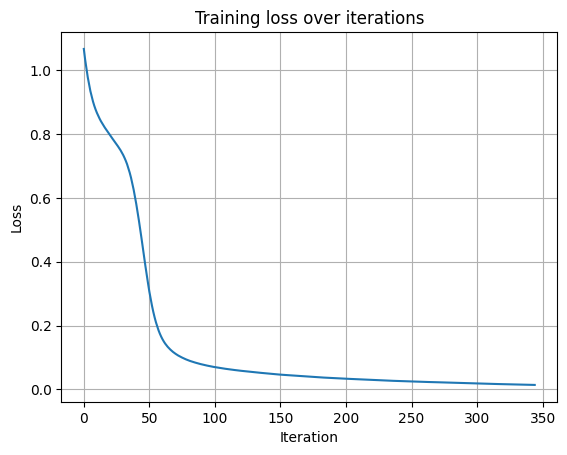

In [7]:
# Plot the loss curve over training iterations
plt.plot(model.loss_curve_)
plt.title("Training loss over iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## 3. Evaluation

Evaluation tells us how well the model performs on **unseen** test data:

1. **Accuracy** — overall fraction correct
2. **Confusion matrix** — where mistakes happen
3. **Precision / Recall / F1** — quality per class
4. **ROC-AUC** — ranking quality across thresholds

### Step 1 — Make predictions

In [8]:
y_pred = model.predict(X_test)             # predicted class (0/1)
y_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1

print("First 10 true labels     :", y_test[:10])
print("First 10 predicted labels:", y_pred[:10])
print("First 10 probabilities   :", np.round(y_proba[:10], 3))

First 10 true labels     : [0 1 0 1 0 1 1 0 0 0]
First 10 predicted labels: [0 1 0 0 0 1 1 0 0 0]
First 10 probabilities   : [0.    1.    0.    0.115 0.    0.999 1.    0.    0.    0.   ]


### Step 2 — Accuracy

In [9]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy = {acc:.4f}  ({acc*100:.2f}% of test samples classified correctly)")

Accuracy = 0.9561  (95.61% of test samples classified correctly)


### Step 3 — Confusion matrix

Rows = actual class, columns = predicted class. The diagonal is correct predictions.

Confusion matrix:
 [[41  1]
 [ 4 68]]


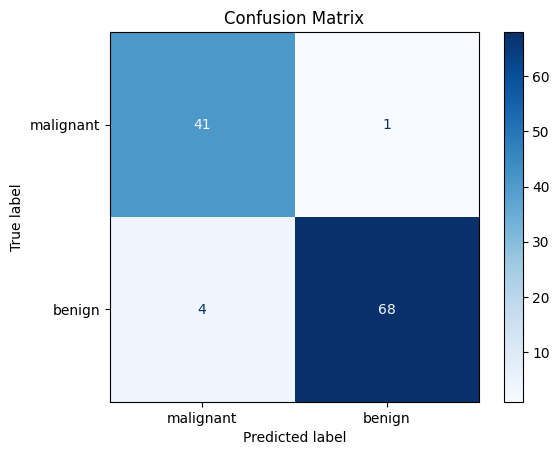

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

### Step 4 — Precision, Recall, F1 (classification report)

- **Precision**: of those predicted positive, how many were right?
- **Recall**: of all real positives, how many did we catch?
- **F1**: harmonic mean of precision and recall.

In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



### Step 5 — ROC curve and AUC

AUC (area under the ROC curve) measures how well the model ranks positives above negatives. 1.0 = perfect, 0.5 = random guessing.

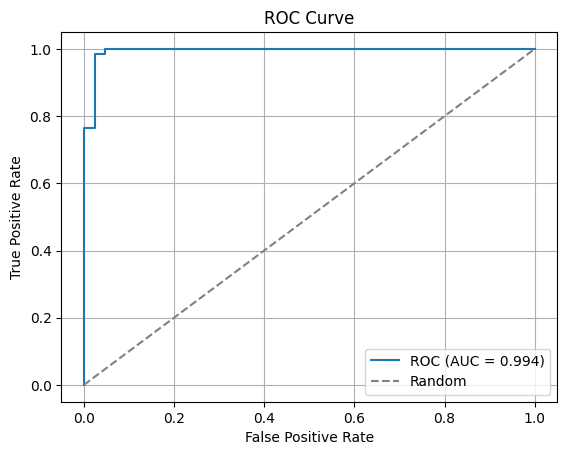

ROC-AUC = 0.9940


In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

auc = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], '--', color='gray', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC-AUC = {auc:.4f}")

In [15]:
!pip install tensorflow

zsh:1: command not found: pip


---
# Part 2 — Neural Network with TensorFlow / Keras

TensorFlow (Keras) is the industry-standard library for deep learning. Here we:

1. Build a model by **adding layers**
2. **Train** it over multiple **epochs**
3. Plot the training history and **evaluate**

We reuse the scaled `X_train`, `X_test`, `y_train`, `y_test` from Part 1.

## 2.1 Install and import TensorFlow

In [16]:
import sys
!{sys.executable} -m pip install tensorflow

import tensorflow as tf
from tensorflow import keras

print("TensorFlow version:", tf.__version__)
tf.random.set_seed(42)

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.2/223.2 MB 23.3 MB/s  0:00:09m0:00:0100:0

## 2.2 Build the network by adding layers

With Keras we stack layers in a `Sequential` model. Each `Dense` layer is a full layer of neurons (weighted sum + bias + activation).

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Build the network by adding layers one at a time
model_tf = Sequential()
model_tf.add(Input(shape=(X_train.shape[1],)))   # input layer (30 features)
model_tf.add(Dense(16, activation='relu'))        # hidden layer 1
model_tf.add(Dense(8, activation='relu'))         # hidden layer 2
model_tf.add(Dense(1, activation='sigmoid'))      # output layer (binary)

# Compile: choose loss, optimizer and metric
model_tf.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_tf.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

## 2.3 Train over epochs

An **epoch** is one complete pass through the training data. Over many epochs the network gradually lowers its loss.

In [19]:
# Train the model
history = model_tf.fit(
    X_train, y_train,
    validation_split=0.2,   # hold out 20% of training data for validation
    epochs=50,              # number of passes over the data
    batch_size=32,          # samples processed before each weight update
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5192 - loss: 0.7097 - val_accuracy: 0.7802 - val_loss: 0.5254
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7940 - loss: 0.4894 - val_accuracy: 0.8901 - val_loss: 0.3917
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9148 - loss: 0.3639 - val_accuracy: 0.9451 - val_loss: 0.3127
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9451 - loss: 0.2902 - val_accuracy: 0.9560 - val_loss: 0.2595
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9505 - loss: 0.2415 - val_accuracy: 0.9560 - val_loss: 0.2213
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9505 - loss: 0.2060 - val_accuracy: 0.9560 - val_loss: 0.1920
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9615 - loss: 0.1794 - val_accuracy: 0.9670 - val_loss: 0.1665
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9643 - loss: 0.1589 - val_accuracy: 0.9780 - val_loss:

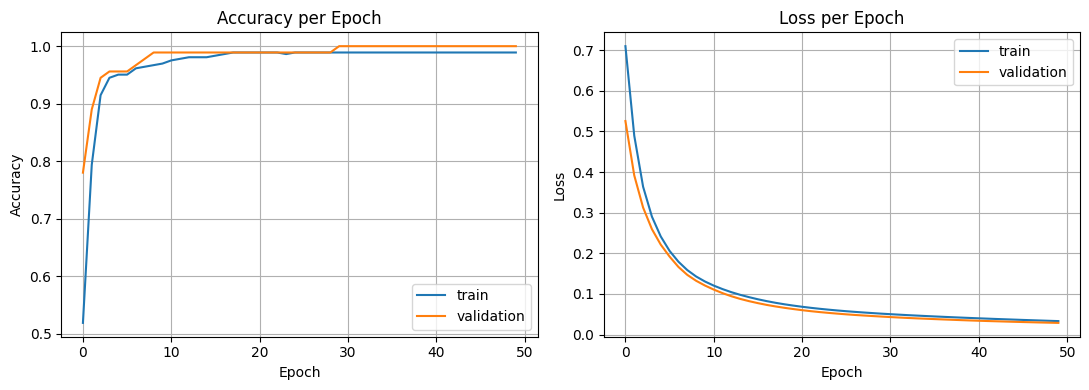

In [20]:
# Plot accuracy and loss across epochs
hist = history.history

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(hist['accuracy'], label='train')
axes[0].plot(hist['val_accuracy'], label='validation')
axes[0].set_title('Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist['loss'], label='train')
axes[1].plot(hist['val_loss'], label='validation')
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 2.4 Evaluate the TensorFlow model

Same evaluation as Part 1: accuracy, confusion matrix, and classification report.

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

# Probabilities -> class labels using 0.5 threshold
tf_proba = model_tf.predict(X_test).ravel()
tf_pred = (tf_proba >= 0.5).astype(int)

# Accuracy from Keras evaluate
loss_tf, acc_tf = model_tf.evaluate(X_test, y_test, verbose=0)
print(f"Test loss     = {loss_tf:.4f}")
print(f"Test accuracy = {acc_tf:.4f}")
print()

# Confusion matrix
print("Confusion matrix:\n", confusion_matrix(y_test, tf_pred))
print()

# Precision / Recall / F1
print(classification_report(y_test, tf_pred, target_names=data.target_names))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Test loss     = 0.1122
Test accuracy = 0.9474

Confusion matrix:
 [[40  2]
 [ 4 68]]

              precision    recall  f1-score   support

   malignant       0.91      0.95      0.93        42
      benign       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



---
## Summary

| | **Part 1 — sklearn MLPClassifier** | **Part 2 — TensorFlow / Keras** |
|---|---|---|
| Setup | `MLPClassifier(hidden_layer_sizes=(16,8))` | `Sequential()` + `Dense` layers |
| Training | `.fit(X_train, y_train)` | `.fit(X_train, y_train, epochs=50)` |
| Flexibility | Simple, quick prototyping | Full control over architecture, callbacks, GPU |
| Use case | Tabular data, small-medium problems | Deep learning, images, text, large-scale |

**Evaluation checklist** (same for both): predictions → accuracy → confusion matrix → precision/recall/F1 → ROC-AUC